# Qwen3-14B × KoAlpaca LoRA Fine-tuning
OpenMathReasoning(25%) + KoAlpaca(75%) 혼합 데이터로 파인튜닝 후 한국어 응답 품질을 비교한다.


## 1. GPU 환경 확인

In [1]:
import torch

# CUDA 디바이스 0번(첫 번째 GPU)의 속성을 조회한다.
# 멀티 GPU 환경이라면 device index를 변경해야 한다.
gpu = torch.cuda.get_device_properties(0)
print(f'GPU  : {gpu.name}')
print(f'VRAM : {round(gpu.total_memory / 1024**3, 1)} GB')
print(f'CUDA : {torch.version.cuda}')

GPU  : NVIDIA H100 80GB HBM3
VRAM : 79.2 GB
CUDA : 12.8


## 2. 패키지 설치

In [ ]:
# unsloth          : LoRA 학습 및 4bit 양자화 추론 최적화 라이브러리. HuggingFace PEFT 대비 학습 속도 향상
# datasets          : HuggingFace Hub에서 데이터셋을 다운로드·전처리하는 라이브러리
# trl               : SFT(Supervised Fine-Tuning) 트레이너를 제공하는 라이브러리
# matplotlib        : 학습 loss curve 시각화에 사용
# koreanize-matplotlib: matplotlib 한글 폰트 자동 적용
!pip install unsloth datasets trl matplotlib koreanize-matplotlib -q


INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 123.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 83.3 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 156.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 134.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 190.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.5/915.5 MB 95.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.2/188.2 MB 109.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 154.5 MB/s eta 0:00:00
   ━━━━━━━━━━━

## 3. 모델 로드

In [2]:
from unsloth import FastLanguageModel

# unsloth Hub에서 Qwen3-14B 가중치를 다운로드하고 4bit NF4 양자화로 로드한다.
# load_in_4bit=True : 가중치를 4bit로 양자화하여 VRAM 사용량을 절반 이하로 줄인다.
#                     단, 추론 시 dequantize 오버헤드가 발생하므로 속도는 소폭 감소한다.
# max_seq_length=2048: 입력 + 출력 토큰의 최대 합산 길이. 이 값을 초과하는 샘플은
#                      자동으로 잘리므로(truncation) 데이터 분포에 따라 조정이 필요하다.
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = 'unsloth/Qwen3-14B',
    max_seq_length = 2048,
    load_in_4bit   = True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.2: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.205 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/443 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-14b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [3]:
# 학습 전 디스크 여유 공간을 확인한다. 데이터셋 다운로드 및 체크포인트 저장에 충분한지 점검한다.
!df -h /


Filesystem      Size  Used Avail Use% Mounted on
overlay          50G   26G   25G  51% /


## 4. LoRA 설정
- `r=32`: 영어→한국어 도메인 변화가 크므로 표현력 높게 설정
- `lora_alpha=32`: 스케일링 계수 alpha/r=1.0, 학습 안정성 우선
- `target_modules`: Attention + FFN 전체에 부착


In [4]:
# LoRA(Low-Rank Adaptation) 어댑터를 모델에 부착한다.
# 원본 가중치는 동결(freeze)되고, 각 레이어에 삽입된 저랭크 행렬(A, B)만 학습된다.
# 전체 파라미터의 극히 일부만 업데이트하므로 메모리와 연산량을 대폭 절감한다.
model = FastLanguageModel.get_peft_model(
    model,
    # r : LoRA 저랭크 행렬의 랭크(차원).
    #     값이 클수록 표현력이 높아지나 학습 파라미터 수와 메모리 사용량도 증가한다.
    #     영어→한국어 도메인 이동 폭이 크므로 r=32로 설정한다.
    r              = 32,
    # lora_alpha : LoRA 출력에 곱해지는 스케일링 계수. 실질적인 학습률 배율로 작용한다.
    #              alpha/r = 1.0 으로 설정하면 스케일 중립적이라 학습이 안정적이다.
    lora_alpha     = 32,
    # target_modules : LoRA 어댑터를 삽입할 레이어 목록.
    #                  q/k/v/o_proj  : Attention 입출력 투영 행렬
    #                  gate/up/down_proj : FFN(SwiGLU) 구성 행렬
    #                  Attention과 FFN 모두에 부착하여 충분한 표현력을 확보한다.
    target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
                      'gate_proj', 'up_proj', 'down_proj'],
    # lora_dropout : 어댑터 레이어에 적용할 드롭아웃 비율.
    #                데이터가 충분하고 스텝 수가 적으므로 0으로 설정한다.
    lora_dropout   = 0,
    # bias : LoRA 어댑터의 bias 학습 여부. 'none'이 일반적으로 권장된다.
    bias           = 'none',
    # use_gradient_checkpointing : 순전파 중간 활성화값을 저장하지 않고 역전파 시 재계산한다.
    #                              'unsloth' 옵션은 unsloth 최적화 구현체를 사용한다.
    #                              VRAM을 추가로 절감하는 대신 역전파 연산량이 소폭 증가한다.
    use_gradient_checkpointing = 'unsloth',
    random_state   = 3407,
)

# 전체 파라미터 중 실제 학습되는 파라미터 비율을 출력한다.
# LoRA의 경우 통상 0.5~2% 수준으로, 전체 파인튜닝 대비 메모리를 대폭 절감한다.
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'학습 파라미터 비율: {trainable/total*100:.2f}%')

Unsloth 2026.4.2 patched 40 layers with 40 QKV layers, 40 O layers and 40 MLP layers.


학습 파라미터 비율: 1.48%


## 5. 데이터 준비
- **OpenMathReasoning** (25%): reasoning 능력 유지 (영어 CoT)
- **KoAlpaca** (75%): 한국어 instruction following 강화
- 두 데이터를 섞는 이유: KoAlpaca만 쓰면 reasoning 능력이 퇴화(Catastrophic Forgetting)


In [5]:
from datasets import load_dataset

# OpenMathReasoning-mini : NVIDIA가 공개한 수학 추론 데이터셋의 경량 버전.
#                          CoT(Chain-of-Thought) split을 사용하여 단계별 풀이 형식을 학습시킨다.
#                          영어 데이터이지만 reasoning 능력 유지를 위해 혼합에 포함한다.
reasoning_dataset = load_dataset('unsloth/OpenMathReasoning-mini', split='cot')

# KoAlpaca-v1.1a : 한국어 instruction-following 데이터셋.
#                  instruction / input / output 세 필드로 구성되며,
#                  한국어 응답 품질 향상의 핵심 학습 데이터로 사용한다.
koalpaca_dataset  = load_dataset('Beomi/KoAlpaca-v1.1a', split='train')

print(f'OpenMathReasoning: {len(reasoning_dataset):,}건')
print(f'KoAlpaca         : {len(koalpaca_dataset):,}건')

README.md:   0%|          | 0.00/603 [00:00<?, ?B/s]

data/cot-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

Generating cot split:   0%|          | 0/19252 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-21df739eb88d71(…):   0%|          | 0.00/12.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21155 [00:00<?, ? examples/s]

OpenMathReasoning: 19,252건
KoAlpaca         : 21,155건


In [10]:
def convert_reasoning(examples):
    conversations = []
    for problem, solution in zip(examples['problem'], examples['generated_solution']):
        conversations.append([
            {'role': 'user',      'content': problem},
            {'role': 'assistant', 'content': solution},
        ])
    return {'conversations': conversations}

def convert_koalpaca(examples):
    conversations = []
    for inst, out in zip(examples['instruction'], examples['output']):
        conversations.append([
            {'role': 'user',      'content': inst},
            {'role': 'assistant', 'content': out},
        ])
    return {'conversations': conversations}

# 개별 적용
reasoning_texts = [
    tokenizer.apply_chat_template(conv, tokenize=False)
    for conv in reasoning_dataset.map(convert_reasoning, batched=True)['conversations']
]

koalpaca_texts = [
    tokenizer.apply_chat_template(conv, tokenize=False)
    for conv in koalpaca_dataset.map(convert_koalpaca, batched=True)['conversations']
]

print(f'reasoning: {len(reasoning_texts):,}건')
print(f'koalpaca : {len(koalpaca_texts):,}건')

Map:   0%|          | 0/21155 [00:00<?, ? examples/s]

reasoning: 19,252건
koalpaca : 21,155건


In [14]:
import pandas as pd
from datasets import Dataset

# KoAlpaca만으로 학습하면 기존에 학습된 reasoning 능력이 손상(Catastrophic Forgetting)된다.
# 이를 방지하기 위해 reasoning 25% : KoAlpaca 75% 비율로 데이터를 혼합한다.
n = len(reasoning_texts)

# reasoning:koalpaca = 1:3 → 25%:75% 비율을 맞추기 위해 reasoning 샘플 수의 3배를 샘플링한다.
koalpaca_sample = pd.Series(koalpaca_texts).sample(
    min(int(n * 3), len(koalpaca_texts)),  # 전체 초과 방지
    random_state=2407
)

# 두 시리즈를 합쳐 하나의 DataFrame으로 구성하고 HuggingFace Dataset으로 변환한다.
# shuffle로 두 데이터셋이 배치 단위로 뭉치지 않도록 무작위 섞기를 수행한다.
data = pd.concat([pd.Series(reasoning_texts), koalpaca_sample])
data.name = 'text'
combined_dataset = Dataset.from_pandas(pd.DataFrame(data)).shuffle(seed=3407)

print(f'reasoning : {n:,}건 (25%)')
print(f'koalpaca  : {len(koalpaca_sample):,}건 (75%)')
print(f'total     : {len(combined_dataset):,}건')

reasoning : 19,252건 (25%)
koalpaca  : 21,155건 (75%)
total     : 40,407건


## 6. Base 응답 저장
> ⚠️ **학습(Cell 7) 전에 반드시 실행** — 학습 후에는 가중치가 바뀌어 재현 불가


In [15]:
import json, re, time

# 정성 평가에 사용할 프롬프트 5개.
# 실생활 상식, 수학 추론, CS 개념, 논리, 머신러닝 등 다양한 도메인을 포함한다.
# 학습 전후 응답을 동일한 프롬프트로 비교하여 품질 변화를 관찰한다.
EVAL_PROMPTS = [
    '전세 계약할 때 주의해야 할 점이 뭐야?',
    '1부터 100까지 더하면 얼마야? 풀이 과정도 설명해줘.',
    '추천 시스템에서 콜드 스타트 문제란 뭐야?',
    '닭이 먼저야 달걀이 먼저야? 논리적으로 설명해줘.',
    '데이터 불균형 문제를 어떻게 해결해?',
]

def generate(prompt, thinking=False):
    # 단일 user 턴으로 구성된 messages를 chat template으로 직렬화한다.
    # enable_thinking=True 시 <think>...</think> 블록 내부에서 내부 추론을 수행하며,
    # temperature와 top_p를 더 낮게 설정하여 추론의 일관성을 높인다.
    messages = [{'role': 'user', 'content': prompt}]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False,
        add_generation_prompt=True,
        enable_thinking=thinking,
    )
    inputs = tokenizer(text, return_tensors='pt').to('cuda')

    # torch.no_grad() : 추론 시 gradient를 계산하지 않아 메모리와 연산량을 절감한다.
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens = 512,
            # thinking 모드 ON : 낮은 temperature로 논리적 일관성을 우선한다.
            # thinking 모드 OFF: 높은 temperature로 자연스러운 응답 다양성을 확보한다.
            temperature    = 0.6 if thinking else 0.7,
            top_p          = 0.95 if thinking else 0.8,
            top_k          = 20,
            do_sample      = True,
        )
    # 입력 토큰 수만큼 앞부분을 제거하여 생성된 응답 부분만 디코딩한다.
    n_input = inputs['input_ids'].shape[1]
    return tokenizer.decode(output[0][n_input:], skip_special_tokens=True)

# 학습 전 base 모델의 응답을 생성하고 JSON으로 저장한다.
# 이 셀은 반드시 학습(Cell 7) 이전에 실행해야 한다.
# 학습 후에는 가중치가 변경되어 base 응답을 재현할 수 없다.
start = time.time()
base_results = []
for prompt in EVAL_PROMPTS:
    print(f'생성 중: {prompt[:20]}...')
    base_results.append({
        'prompt'      : prompt,
        'thinking_off': generate(prompt, thinking=False),
        'thinking_on' : generate(prompt, thinking=True),
    })

with open('base_results.json', 'w', encoding='utf-8') as f:
    json.dump(base_results, f, ensure_ascii=False, indent=2)
print(f'저장 완료: base_results.json')
print(f'Base 응답 생성 시간: {round((time.time()-start)/60, 1)}분')

Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


생성 중: 전세 계약할 때 주의해야 할 점이 뭐...


/usr/local/lib/python3.11/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.11/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5

생성 중: 1부터 100까지 더하면 얼마야? 풀...


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

생성 중: 닭이 먼저야 달걀이 먼저야? 논리적으...


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


생성 중: 데이터 불균형 문제를 어떻게 해결해?...


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


저장 완료: base_results.json
Base 응답 생성 시간: 2.7분


## 7. 학습

>**실험 설정 안내**: H100(80GB) 환경에서 `max_steps=500`로 loss curve 수렴을 확인한다.  
> 유효 배치 크기 16(per_device=4 × grad_accum=4)으로 총 8,000개 샘플을 학습에 사용한다.  
> 프로덕션 수준의 품질을 목표로 한다면 1,000 스텝 이상이 권장된다.


In [16]:
from trl import SFTTrainer, SFTConfig
import time

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = combined_dataset,
    args          = SFTConfig(
        # dataset_text_field : Dataset에서 학습에 사용할 텍스트 컬럼명을 지정한다.
        dataset_text_field          = 'text',
        # per_device_train_batch_size : GPU 1개당 미니배치 크기.
        #   H100 80GB VRAM을 활용하여 RTX 계열 대비 배치 크기를 2→4로 늘렸다.
        per_device_train_batch_size = 4,
        # gradient_accumulation_steps : 실제 optimizer step 전 gradient를 누적할 스텝 수.
        #   유효 배치 크기 = per_device_train_batch_size × gradient_accumulation_steps = 16
        gradient_accumulation_steps = 4,
        # warmup_steps : 학습 초반 learning rate를 0에서 목표값까지 선형으로 증가시키는 스텝 수.
        #   초기 gradient 폭발을 방지하기 위해 사용한다.
        warmup_steps                = 10,
        # max_steps : 총 학습 스텝 수.
        #   H100 환경에서 loss curve 수렴을 확인하기 위해 500으로 설정한다.
        #   유효 배치 16 기준 총 8,000개 샘플을 학습에 사용한다.
        max_steps                   = 500,
        # learning_rate : AdamW optimizer의 기본 학습률.
        #   LoRA 파인튜닝에서는 2e-4가 일반적인 출발점이다.
        learning_rate               = 2e-4,
        # logging_steps : 이 스텝 간격마다 loss 등 학습 지표를 기록한다.
        logging_steps               = 10,
        # optim : 8bit AdamW를 사용하여 optimizer state의 메모리 사용량을 줄인다.
        #   일반 AdamW 대비 optimizer state를 약 75% 절감한다.
        optim                       = 'adamw_8bit',
        # weight_decay : L2 정규화 계수. 과적합 방지를 위해 가중치 크기에 패널티를 부여한다.
        weight_decay                = 0.01,
        # lr_scheduler_type : warmup 이후 learning rate를 0까지 선형 감소시킨다.
        lr_scheduler_type           = 'linear',
        seed                        = 3407,
        # report_to='none' : wandb, tensorboard 등 외부 로깅 서비스에 보고하지 않는다.
        report_to                   = 'none',
    ),
)

start = time.time()
trainer.train()
print(f'학습 완료: {round((time.time()-start)/60, 1)}분')

Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/40407 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 40,407 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 128,450,560 of 14,896,757,760 (0.86% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,0.674489
20,0.616589
30,0.545649
40,0.541408
50,0.589452
60,0.586307
70,0.587371
80,0.553198
90,0.627517
100,0.525129


학습 완료: 29.9분


## 8. Loss Curve

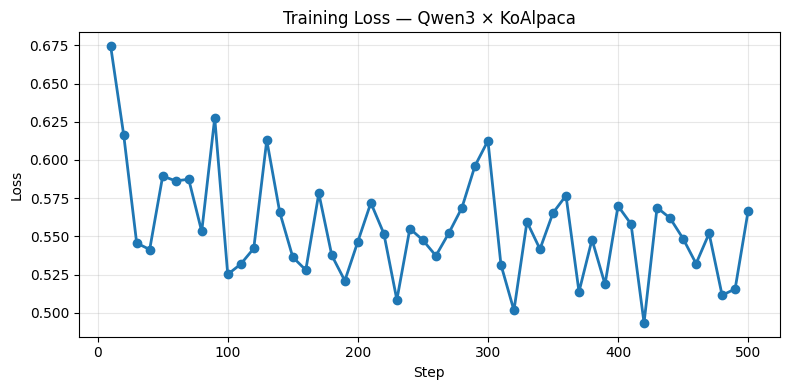

In [17]:
import matplotlib.pyplot as plt, os

# trainer.state.log_history : 학습 중 기록된 딕셔너리 리스트.
# 'loss' 키가 있는 항목만 필터링하여 step별 loss 값을 추출한다.
logs   = trainer.state.log_history
steps  = [x['step'] for x in logs if 'loss' in x]
losses = [x['loss']  for x in logs if 'loss' in x]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker='o', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss — Qwen3 × KoAlpaca')
plt.grid(alpha=0.3)
plt.tight_layout()

# figures/ 디렉터리가 없으면 생성하고 loss curve를 PNG로 저장한다.
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/loss_curve.png', dpi=150)
plt.show()

## 9. Fine-tuned 응답 생성

In [18]:
# 학습 후 fine-tuned 모델의 응답을 생성하고 JSON으로 저장한다.
# base_results.json과 동일한 프롬프트를 사용하므로 셀 22에서 직접 비교가 가능하다.
start = time.time()
ft_results = []
for prompt in EVAL_PROMPTS:
    print(f'생성 중: {prompt[:20]}...')
    ft_results.append({
        'prompt'      : prompt,
        'thinking_off': generate(prompt, thinking=False),
        'thinking_on' : generate(prompt, thinking=True),
    })

with open('ft_results.json', 'w', encoding='utf-8') as f:
    json.dump(ft_results, f, ensure_ascii=False, indent=2)
print(f'저장 완료: ft_results.json')
print(f'FT 응답 생성 시간: {round((time.time()-start)/60, 1)}분')

Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


생성 중: 전세 계약할 때 주의해야 할 점이 뭐...


/usr/local/lib/python3.11/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.11/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5

생성 중: 1부터 100까지 더하면 얼마야? 풀...


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

생성 중: 닭이 먼저야 달걀이 먼저야? 논리적으...


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


생성 중: 데이터 불균형 문제를 어떻게 해결해?...


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


저장 완료: ft_results.json
FT 응답 생성 시간: 1.6분


## 10. Before / After 비교
세 가지 포인트를 직접 관찰한다.
1. 한국어 응답 여부
2. 응답 구체성
3. `<think>` 내부가 영어인지 한국어인지


In [19]:
# base 모델과 fine-tuned 모델의 응답을 프롬프트별로 나란히 출력하여 비교한다.
# 각 응답은 300자로 잘라 터미널 출력을 간결하게 유지한다.
# 관찰 포인트:
#   1. 한국어 응답 여부 (base는 영어로 답할 수 있음)
#   2. 응답 구체성 및 정보량 변화
#   3. thinking ON 시 <think> 블록 내부가 영어인지 한국어인지
for base, ft in zip(base_results, ft_results):
    print('=' * 60)
    print(f"Q: {base['prompt']}")
    print()
    print(f"[BASE  / thinking OFF]\n{base['thinking_off'][:300]}")
    print()
    print(f"[FT    / thinking OFF]\n{ft['thinking_off'][:300]}")
    print()
    print(f"[BASE  / thinking ON ]\n{base['thinking_on'][:300]}")
    print()
    print(f"[FT    / thinking ON ]\n{ft['thinking_on'][:300]}")
    print()

Q: 전세 계약할 때 주의해야 할 점이 뭐야?

[BASE  / thinking OFF]
전세 계약을 할 때에는 **계약 전에 꼼꼼히 확인**하고, **법적, 재정적 위험을 최소화**하기 위해 몇 가지 주의 사항을 꼭 알아야 합니다. 아래는 전세 계약 시 주의해야 할 주요 사항들입니다:

---

### 1. **계약서를 꼼꼼히 확인하세요**
- **계약서의 내용을 반드시 확인**하고, **계약서에 기재된 내용이 실제 입주 조건과 일치하는지** 확인하세요.
- **계약 기간, 전세금 납부 일정, 보증금, 계약 해지 조건, 위약금 등**이 명확히 기재되어 있는지 확인합니다.
- **계약서에 명시되지 않은 내용**은 **추

[FT    / thinking OFF]
전세 계약을 할 때는 주의해야 할 여러 가지 사항이 있습니다. 먼저, 전세 계약서를 작성할 때에는 계약금과 보증금의 구분이 명확해야 합니다. 또한, 계약서에는 전세계약의 목적, 대상물건, 전세금액, 전세금의 납부방법, 전세계약의 기간, 전세계약의 해약조건, 보증금의 처리방법, 계약서의 유효기간 등이 명시되어 있어야 합니다. 또한, 전세계약서에는 전세계약에 따라 전세금을 지급받은 사람이 전세계약의 목적물에 대한 소유권을 얻는 것이 아니라는 점을 명시해야 합니다. 마지막으로, 전세계약서에는 전세계약에 따라 전세금을 지급받은 사람이 전세

[BASE  / thinking ON ]
<think>
Okay, the user is asking about things to be careful about when signing a lease agreement. Let me start by recalling the key points that are usually important in lease contracts.

First, I should mention the contract period. It's crucial to know how long the lease is for because that affects 

## 11-1. 응답 길이 비교
thinking ON/OFF 별로 base와 fine-tuned 모델의 응답 길이(문자 수) 변화를 시각화한다.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False

# 각 프롬프트별로 base/FT 모델의 응답 길이(문자 수)를 추출한다.
labels      = [f'Q{i+1}' for i in range(len(base_results))]
base_off    = [len(r['thinking_off']) for r in base_results]
base_on     = [len(r['thinking_on'])  for r in base_results]
ft_off      = [len(r['thinking_off']) for r in ft_results]
ft_on       = [len(r['thinking_on'])  for r in ft_results]

x     = np.arange(len(labels))
width = 0.2  # 막대 너비

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- thinking OFF 비교 ---
ax = axes[0]
ax.bar(x - width/2, base_off, width, label='Base',        color='steelblue',  alpha=0.85)
ax.bar(x + width/2, ft_off,   width, label='Fine-tuned',  color='darkorange', alpha=0.85)
ax.set_title('응답 길이 비교 — Thinking OFF')
ax.set_xlabel('프롬프트')
ax.set_ylabel('응답 길이 (문자 수)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# --- thinking ON 비교 ---
ax = axes[1]
ax.bar(x - width/2, base_on, width, label='Base',        color='steelblue',  alpha=0.85)
ax.bar(x + width/2, ft_on,   width, label='Fine-tuned',  color='darkorange', alpha=0.85)
ax.set_title('응답 길이 비교 — Thinking ON')
ax.set_xlabel('프롬프트')
ax.set_ylabel('응답 길이 (문자 수)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Q1~Q5 프롬프트 전문을 범례 아래에 표기한다.
prompt_legend = '\n'.join([f'Q{i+1}: {p}' for i, p in enumerate(EVAL_PROMPTS)])
fig.text(0.5, -0.08, prompt_legend, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('figures/response_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: figures/response_length.png')

NameError: name 'base_results' is not defined

## 11-2. 한국어 비율 비교

파인튜닝의 핵심 목표인 **한국어 응답 개선**을 정량적으로 측정한다.
한글 문자(가-힣) 수를 전체 문자 수(공백 제외)로 나눠 한국어 비율을 계산한다.


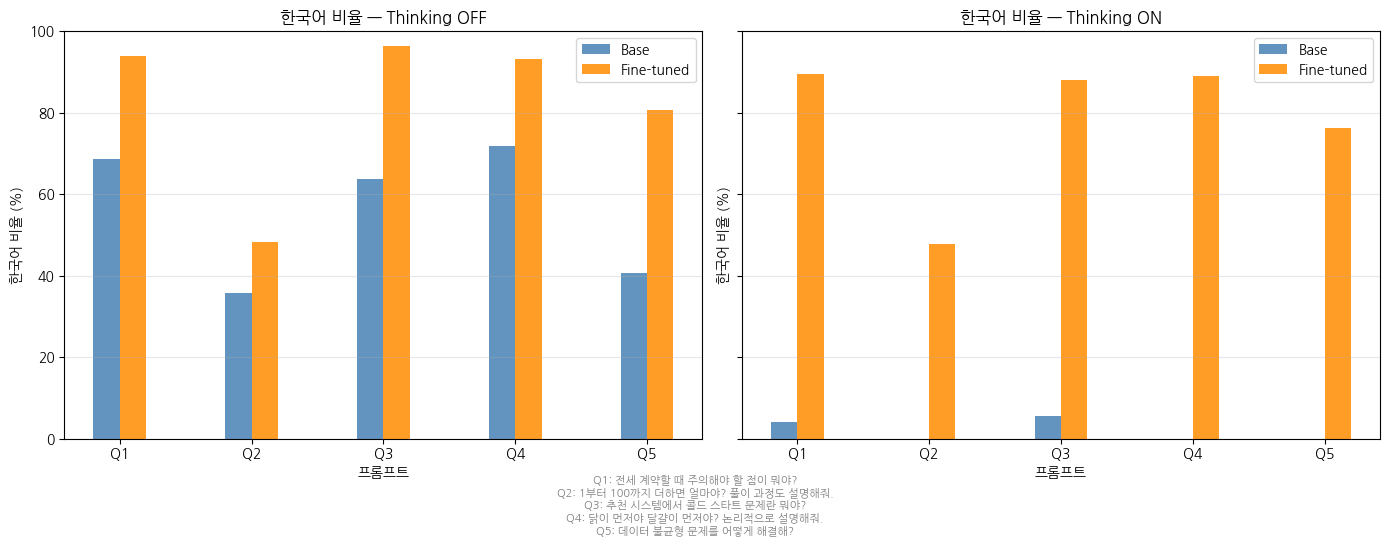

                                 Thinking OFF  Thinking ON
Base   평균 한국어 비율                        56.1%         1.9%
FT     평균 한국어 비율                        82.5%        78.2%
저장 완료: figures/korean_ratio.png


In [32]:
import json, re
import matplotlib.pyplot as plt
import numpy as np
import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False

with open('base_results.json', encoding='utf-8') as f:
    base_results = json.load(f)
with open('ft_results.json', encoding='utf-8') as f:
    ft_results = json.load(f)

EVAL_PROMPTS = [r['prompt'] for r in base_results]

def strip_thinking(text):
    # <think>...</think> 블록(영어 내부 추론)을 제거하고 최종 답변만 반환한다.
    return re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()

def korean_ratio(text):
    # 한글 유니코드 범위(가-힣)에 해당하는 문자 수를 센다.
    # 공백을 제외한 전체 문자 수로 나눠 비율을 계산한다.
    korean = len(re.findall(r'[가-힣]', text))
    total  = len(text.replace(' ', ''))
    return korean / total * 100 if total > 0 else 0

labels = [f'Q{i+1}' for i in range(len(base_results))]
x      = np.arange(len(labels))
width  = 0.2

# thinking OFF : 그대로 측정
# thinking ON  : <think> 블록은 설계상 영어로 생성되므로 제거 후 최종 답변만 측정
base_kr_off = [korean_ratio(r['thinking_off'])                for r in base_results]
base_kr_on  = [korean_ratio(strip_thinking(r['thinking_on'])) for r in base_results]
ft_kr_off   = [korean_ratio(r['thinking_off'])                for r in ft_results]
ft_kr_on    = [korean_ratio(strip_thinking(r['thinking_on'])) for r in ft_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, base_vals, ft_vals, title in [
    (axes[0], base_kr_off, ft_kr_off, '한국어 비율 — Thinking OFF'),
    (axes[1], base_kr_on,  ft_kr_on,  '한국어 비율 — Thinking ON (think 블록 제외)'),
]:
    ax.bar(x - width/2, base_vals, width, label='Base',       color='steelblue',  alpha=0.85)
    ax.bar(x + width/2, ft_vals,   width, label='Fine-tuned', color='darkorange', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('프롬프트')
    ax.set_ylabel('한국어 비율 (%)')
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

prompt_legend = '\n'.join([f'Q{i+1}: {p}' for i, p in enumerate(EVAL_PROMPTS)])
fig.text(0.5, -0.08, prompt_legend, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('figures/korean_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'':30s} {'Thinking OFF':>14} {'Thinking ON':>12}")
print(f"Base  평균 한국어 비율          {np.mean(base_kr_off):>13.1f}% {np.mean(base_kr_on):>11.1f}%")
print(f"FT    평균 한국어 비율          {np.mean(ft_kr_off):>13.1f}% {np.mean(ft_kr_on):>11.1f}%")
print('저장 완료: figures/korean_ratio.png')


## 12. 모델 저장

In [33]:
# LoRA 어댑터 가중치와 토크나이저를 lora_model/ 디렉터리에 저장한다.
# 저장되는 파일: adapter_config.json, adapter_model.safetensors, tokenizer 관련 파일
# 원본 base 모델 가중치는 저장되지 않으므로 용량이 매우 작다(수십~수백 MB 수준).
# 추후 로드 시에는 base 모델과 함께 로드해야 한다.
model.save_pretrained('lora_model')
tokenizer.save_pretrained('lora_model')
print('저장 완료: lora_model/')

저장 완료: lora_model/


## 13. HuggingFace Hub 업로드
어댑터 가중치와 토크나이저를 HuggingFace Hub 레포지토리에 푸시한다.

In [ ]:
import getpass
from huggingface_hub import login

# HuggingFace > Settings > Access Tokens 에서 발급한 write 토큰을 입력한다.
login(token=getpass.getpass('HuggingFace token: '))

In [ ]:
from huggingface_hub import HfApi

HF_REPO = 'your-username/qwen3-14b-koalpaca-lora'

api = HfApi()

# 레포가 없으면 자동 생성한다. private=True 로 설정하면 비공개 레포로 만들어진다.
api.create_repo(repo_id=HF_REPO, repo_type='model', exist_ok=True, private=False)

# upload_folder : lora_model/ 디렉터리 전체를 Hub 레포 루트에 업로드한다.
# 모델 객체 없이 로컬 파일만으로 업로드할 수 있다.
api.upload_folder(
    folder_path = 'lora_model',
    repo_id     = HF_REPO,
    repo_type   = 'model',
)
print(f'업로드 완료: https://huggingface.co/{HF_REPO}')